

%matplotlib inline

## Animation in JupyterLab

These samples are takem from [NumFys](https://www.numfys.net/search/?q=animation) which a project of Jon Andreas Stovneng at the Norwegian University of Science and Technology and Peter Berg at the University of Alberta. What a log of lovely resources at [NumFys](https://www.numfys.net/) their computational physics modules and examples repository. Crikey!!

Let me start by replicating their simple pendulum notebook and it's very basic animation.


In [13]:
import numpy as np

%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt
from matplotlib import animation
matplotlib.rc('animation', html='html5')

from ipywidgets import interact, interactive, widgets
from IPython.display import display

In [20]:
plt.rcParams['animation.ffmpeg_path'] = '/Users/bruceemerson/opt/anaconda3/bin/ffmpeg'

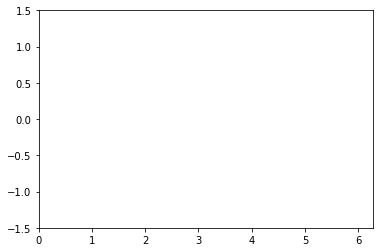

In [14]:
MyFigure, MyAxes = plt.subplots()
MyAxes.set_xlim(( 0, 2*np.pi))
MyAxes.set_ylim((-1.5, 1.5))
MyLine, = MyAxes.plot([], [], lw=2)

In [15]:
x=np.linspace(0,2*np.pi)
AnimationFrames = 100  #total number of frames in animation.
DelayBetweenFrames = 20 #in msec (20 gives 50 fps)
AnimationTime = AnimationFrames * DelayBetweenFrames/1000
print ("The animation will be {:.1f} seconds long.".format(AnimationTime))

The animation will be 2.0 seconds long.


In the following cell, we define the animation function or the function that will be called for each frame. This function should return a tuple of anything that has changed from the previous frame. The function accepts one argument, the number of the animation frame.

Since we want a sin wave that looks like it is continously moving, we will adjust the phase. We adjust the phase by exactly 2$\pi$ over one animation loop so that the animation looks continous.

In [16]:
def a(i):
    y = np.sin(x + 2*np.pi*i/AnimationFrames)
    MyLine.set_data(x, y)
    return (MyLine,)

## Codec Issues

When I first tried to run this animation I had an error trying to load a particular h264 video codec that the animation function want. Took forever to discover that this was the problem. ffmpeg was asking for libopenh264.5.dylib and the codec in the ```/Users/bruceemerson/opt/anaconda3/lib``` was libopenh264.6.dylib. Couldn't for the life of me figure out how to add the codec that was being requested to the library. Eventually was trying to update a couple of packages through conda and updated mkl and suddenly the .6 codec was replaced by the .5 codec. Shit! 

Now everything works!


In [24]:
MyAnimation = animation.FuncAnimation(MyFigure, a,
                               frames=AnimationFrames, interval=DelayBetweenFrames, blit=True)

In [29]:
MyAnimation

In [30]:
MyAnimation.save('testfile.gif', writer = 'ffmpeg')